In [64]:
import os.path, time
import onnxruntime as ort
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.dataset import load_dataset_v2, create_lstm_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from matplotlib.ticker import MultipleLocator, LogLocator
from tqdm.notebook import tqdm

In [65]:
model = ort.InferenceSession('models/model.onnx')

In [73]:
feature_name_list = ['pressure_1(bar)', 'main_pressure(bar)']
target_name = 'outlet_flowrate(lpm)'

file_name_list = os.listdir(os.path.join('data', 'ver_2'))
file_path_list = []

for file_name in file_name_list:
    file_path_list.append(os.path.join('data', 'ver_2', file_name))

dataset = load_dataset_v2(file_path_list)
dataset = dataset[::10]
dataset.reset_index(drop=True, inplace=True)

loading dataset...:   0%|          | 0/84 [00:00<?, ?it/s]

In [4]:
new_dataset = dataset.copy()
new_dataset = new_dataset[new_dataset[target_name] > 1]

train_bool_list = new_dataset['test_case_iter']!=3
train_data = new_dataset[train_bool_list]
train_data.reset_index(drop=True, inplace=True)

val_bool_list = new_dataset['test_case_iter']==3
val_data = new_dataset[val_bool_list]
val_data.reset_index(drop=True, inplace=True)

In [5]:
train_feature = train_data[feature_name_list].to_numpy()
val_feature = val_data[feature_name_list].to_numpy()

train_target = train_data[target_name].to_numpy()
val_target = val_data[target_name].to_numpy()

train_target = train_target.reshape(-1, 1)
val_target = val_target.reshape(-1, 1)

scaler = StandardScaler()
scaler.fit(train_target)

train_target = scaler.transform(train_target)
val_target = scaler.transform(val_target)

print(train_feature.shape, train_target.shape)
print(val_feature.shape, val_target.shape)

print((train_feature.itemsize*train_feature.size)/(1024**2))
print((train_target.itemsize*train_target.size)/(1024**2))

(132546, 2) (132546, 1)
(64001, 2) (64001, 1)
2.022491455078125
1.0112457275390625


In [6]:
seq_len = 30

train_feature, train_target = create_lstm_dataset(np.concatenate([train_feature, train_target.reshape(-1, 1)], axis=1), seq_len=seq_len,
                                                  pred_distance=0, target_idx_pos=train_feature.shape[1])
val_feature, val_target = create_lstm_dataset(np.concatenate([val_feature, val_target.reshape(-1, 1)], axis=1), seq_len=seq_len,
                                              pred_distance=0, target_idx_pos=val_feature.shape[1])

train_target = np.squeeze(train_target)
val_target = np.squeeze(val_target)

print(train_feature.shape, train_target.shape)
print(val_feature.shape, val_target.shape)

print((train_feature.itemsize*train_feature.size)/(1024**2))
print((train_target.itemsize*train_target.size)/(1024**2))

creating LSTM dataset...:   0%|          | 0/132546 [00:00<?, ?it/s]

creating LSTM dataset...:   0%|          | 0/64001 [00:00<?, ?it/s]

(132517, 30, 2) (132517,)
(63972, 30, 2) (63972,)
60.661468505859375
1.0110244750976562


In [7]:
train_feature = train_feature.astype(np.float32)
train_target = train_target.astype(np.float32)

time_list = []
train_pred = []

for input_data in tqdm(train_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    train_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/132517 [00:00<?, ?it/s]

Average inference time per data sequence: 5.497 mile seconds


In [18]:
train_pred_scaled = scaler.inverse_transform(np.array(train_pred).reshape(-1, 1))
train_pred_scaled = np.squeeze(train_pred_scaled)
train_pred_scaled.shape

(132517,)

In [13]:
val_feature = val_feature.astype(np.float32)
val_target = val_target.astype(np.float32)

time_list = []
val_pred = []

for input_data in tqdm(val_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    val_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/63972 [00:00<?, ?it/s]

Average inference time per data sequence: 5.747 mile seconds


In [19]:
val_pred_scaled = scaler.inverse_transform(np.array(val_pred).reshape(-1, 1))
val_pred_scaled = np.squeeze(val_pred_scaled)
val_pred_scaled.shape

(63972,)

In [20]:
train_target_scaled = scaler.inverse_transform(train_target.reshape(-1, 1))
train_target_scaled = np.squeeze(train_target_scaled)

val_target_scaled = scaler.inverse_transform(val_target.reshape(-1, 1))
val_target_scaled = np.squeeze(val_target_scaled)

print(train_target_scaled.shape, val_target_scaled.shape)

(132517,) (63972,)


In [21]:
df = pd.DataFrame(time_arr, columns=['onnx_inference_time(ms)'])
df.to_csv('result/onnx_inference_time.csv', index=False)

In [24]:
print(r2_score(train_target_scaled, train_pred_scaled), r2_score(val_target_scaled, val_pred_scaled))
print(mean_absolute_error(train_target_scaled, train_pred_scaled), mean_absolute_error(val_target_scaled, val_pred_scaled))
print(mean_absolute_percentage_error(train_target_scaled, train_pred_scaled), mean_absolute_percentage_error(val_target_scaled, val_pred_scaled))

0.9773970507784818 0.9429962540065949
50.85286024505635 80.64582031776371
0.19942839417019098 0.34609324894197385


In [28]:
val_abs_error = np.abs(val_target_scaled-val_pred_scaled)
val_rela_error = (val_abs_error / val_target_scaled)*100

In [84]:
print(val_target_scaled.max())
val_data_sliced = val_data[29:]
val_data_sliced.reset_index(drop=True, inplace=True)

flow_range = np.array(range(0, int(val_target_scaled.max())+100, 100))

val_result_df = pd.DataFrame({'Ground Truth Flow Rate(LPM)': val_target_scaled, 'Predicted Flow Rate(LPM)': val_pred_scaled, 'Absolute Error(LPM)': val_abs_error, 'Relative Error(%)': val_rela_error})
val_result_df = pd.concat([val_data_sliced, val_result_df], axis=1)

refine_val_result = []

for idx in range(len(flow_range)-1):
    flow_df = val_result_df[(val_result_df['Ground Truth Flow Rate(LPM)'] >= flow_range[idx]) & (val_result_df['Predicted Flow Rate(LPM)'] < flow_range[idx+1])]
    flow_df.reset_index(drop=True, inplace=True)
    refine_val_result.append(flow_df)

flow_result = []

for flow in refine_val_result:
    flow_result.append([flow['Relative Error(%)'].mean(), flow['Relative Error(%)'].std(), flow['Absolute Error(LPM)'].mean(), flow['Absolute Error(LPM)'].std()])

flow_result = np.array(flow_result)
flow_result = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Std Relative Error(%)', 'Mean Absolute Error(LPM)', 'Std Absolute Error(LPM)'])

2105.28


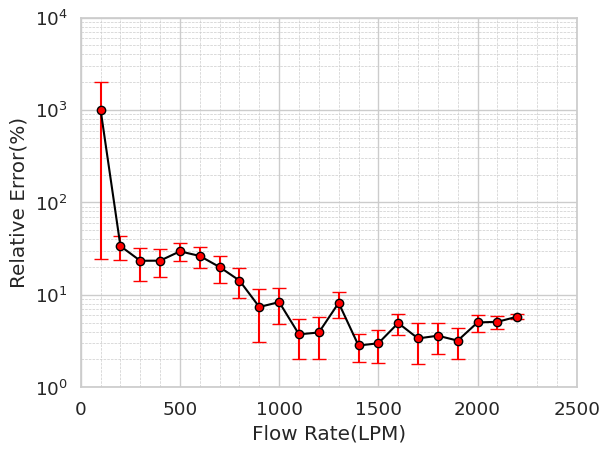

In [85]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

plt.errorbar(flow_result['Flow Rate(LPM)'], flow_result['Mean Relative Error(%)'], yerr=flow_result['Std Relative Error(%)']/2,
             marker='o', markeredgecolor='black', markerfacecolor='red', capsize=5, color='black', ecolor='red')
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.xlim(0, 2500)
plt.xlabel('Flow Rate(LPM)')

plt.ylim(1, 10000)
plt.yscale('log')
plt.ylabel('Relative Error(%)')

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

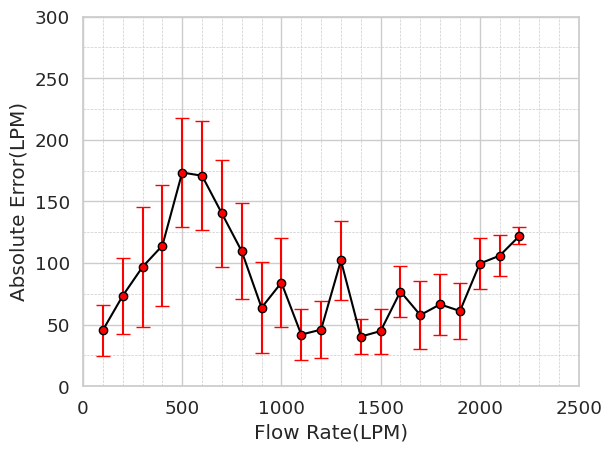

In [86]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

plt.errorbar(flow_result['Flow Rate(LPM)'], flow_result['Mean Absolute Error(LPM)'], yerr=flow_result['Std Absolute Error(LPM)']/2,
             marker='o', markeredgecolor='black', markerfacecolor='red', capsize=5, color='black', ecolor='red')
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.xlim(0, 2500)
plt.xlabel('Flow Rate(LPM)')

plt.ylim(0, 300)
#plt.yscale('log')
plt.ylabel('Absolute Error(LPM)')

#plt.gca().yaxis.set_major_locator(LogLocator(base=10))
plt.gca().yaxis.set_minor_locator(MultipleLocator(25))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

In [88]:
flow_result_rpm_1 = []

for flow in refine_val_result:
    flow = flow[(flow['pump_speed(rpm)'] > 850) & (flow['pump_speed(rpm)'] < 950)]
    flow_result_rpm_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_rpm_1 = np.array(flow_result_rpm_1)
flow_result_rpm_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_rpm_1]),
                                 columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_rpm_2 = []

for flow in refine_val_result:
    flow = flow[(flow['pump_speed(rpm)'] > 1150) & (flow['pump_speed(rpm)'] < 1250)]
    flow_result_rpm_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_rpm_2 = np.array(flow_result_rpm_2)
flow_result_rpm_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_rpm_2]),
                                 columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_rpm_3 = []

for flow in refine_val_result:
    flow = flow[(flow['pump_speed(rpm)'] > 1450) & (flow['pump_speed(rpm)'] < 1550)]
    flow_result_rpm_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_rpm_3 = np.array(flow_result_rpm_3)
flow_result_rpm_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_rpm_3]),
                                 columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

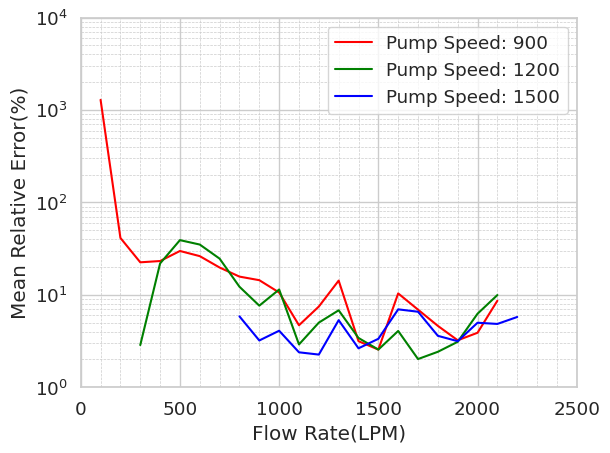

In [95]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_rpm_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Pump Speed: 900')
sns.lineplot(data=flow_result_rpm_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
             label='Pump Speed: 1200')
sns.lineplot(data=flow_result_rpm_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue', marker='',
             label='Pump Speed: 1500')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 10000)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

In [96]:
flow_result_nozzle_dia_1 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_dia(mm)'] ==12.0]
    flow_result_nozzle_dia_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_dia_1 = np.array(flow_result_nozzle_dia_1)
flow_result_nozzle_dia_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_dia_1]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_dia_2 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_dia(mm)'] ==15.8]
    flow_result_nozzle_dia_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_dia_2 = np.array(flow_result_nozzle_dia_2)
flow_result_nozzle_dia_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_dia_2]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_dia_3 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_dia(mm)'] ==20.0]
    flow_result_nozzle_dia_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_dia_3 = np.array(flow_result_nozzle_dia_3)
flow_result_nozzle_dia_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_dia_3]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

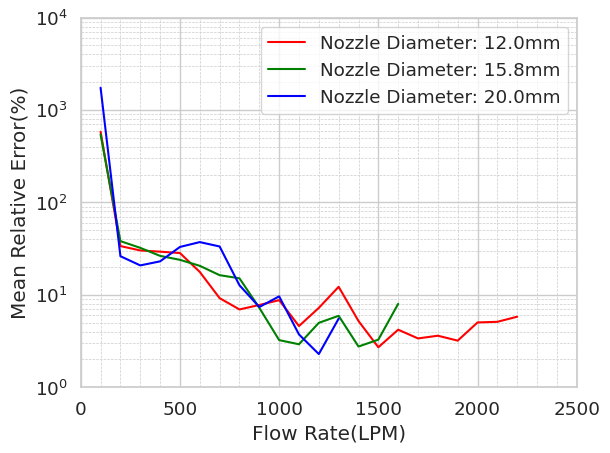

In [105]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_nozzle_dia_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Nozzle Diameter: 12.0mm')
sns.lineplot(data=flow_result_nozzle_dia_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
             label='Nozzle Diameter: 15.8mm')
sns.lineplot(data=flow_result_nozzle_dia_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue', marker='',
             label='Nozzle Diameter: 20.0mm')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 10000)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

In [98]:
flow_result_nozzle_len_1 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_len(mm)'] ==12.0]
    flow_result_nozzle_len_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_len_1 = np.array(flow_result_nozzle_len_1)
flow_result_nozzle_len_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_len_1]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_len_2 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_len(mm)'] ==24.0]
    flow_result_nozzle_len_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_len_2 = np.array(flow_result_nozzle_len_2)
flow_result_nozzle_len_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_len_2]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_len_3 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_len(mm)'] ==36.0]
    flow_result_nozzle_len_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_len_3 = np.array(flow_result_nozzle_len_3)
flow_result_nozzle_len_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_len_3]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

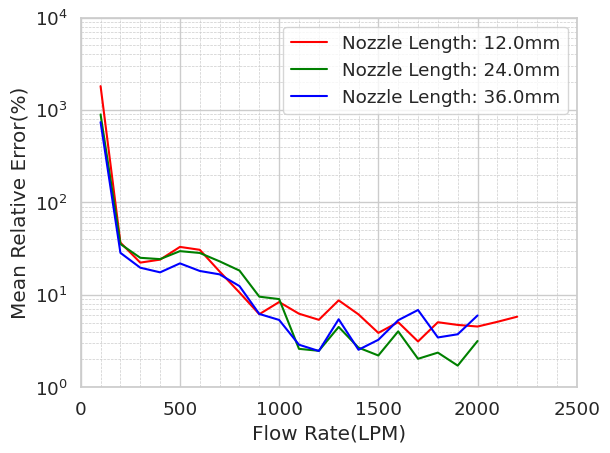

In [104]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_nozzle_len_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Nozzle Length: 12.0mm')
sns.lineplot(data=flow_result_nozzle_len_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
             label='Nozzle Length: 24.0mm')
sns.lineplot(data=flow_result_nozzle_len_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue', marker='',
             label='Nozzle Length: 36.0mm')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 10000)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

In [102]:
flow_result_venturi_dist_1 = []

for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==0.0]
    flow_result_venturi_dist_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_1 = np.array(flow_result_venturi_dist_1)
flow_result_venturi_dist_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_1]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_venturi_dist_2 = []

for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==15.0]
    flow_result_venturi_dist_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_2 = np.array(flow_result_venturi_dist_2)
flow_result_venturi_dist_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_2]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_venturi_dist_3 = []


for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==30.0]
    flow_result_venturi_dist_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_3 = np.array(flow_result_venturi_dist_3)
flow_result_venturi_dist_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_3]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_venturi_dist_4 = []


for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==60.0]
    flow_result_venturi_dist_4.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_4 = np.array(flow_result_venturi_dist_4)
flow_result_venturi_dist_4 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_4]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

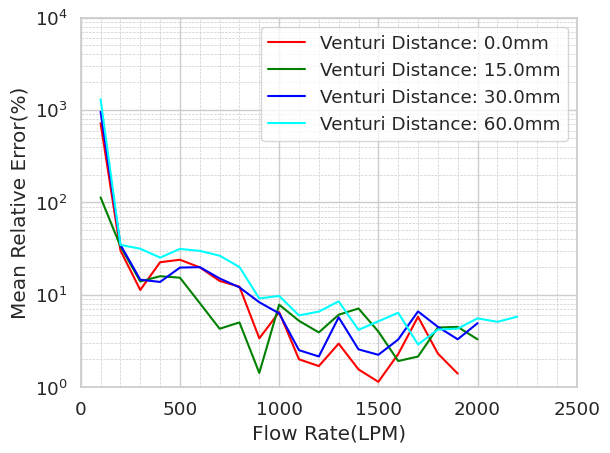

In [106]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_venturi_dist_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Venturi Distance: 0.0mm')
sns.lineplot(data=flow_result_venturi_dist_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
             label='Venturi Distance: 15.0mm')
sns.lineplot(data=flow_result_venturi_dist_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue',
             marker='', label='Venturi Distance: 30.0mm')
sns.lineplot(data=flow_result_venturi_dist_4, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='cyan', marker='',
             label='Venturi Distance: 60.0mm')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 10000)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)